In [1]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu
from scipy import stats


device = eg_utils.get_device()

class RNNModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.rnn = torch.nn.RNNCell(input_size, hidden_size, nonlinearity='relu')
        self.fc = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        x of shape (batch_size, seq_len, input_size)
        out_tensor of shape (batch_size, output_size)
        """
        out_tensor = torch.zeros(x.size(0), x.size(1), self.output_size).to(x.device)
        h_t = torch.zeros(x.size(0), self.hidden_size).to(x.device)
        for t in range(x.size(1)):
            h_t = self.rnn(x[ :,t,: :], h_t)
            out_tensor[:,t, :] = self.fc(h_t)
        return out_tensor

[]
No fonts found


In [2]:
!mkdir figs/figS2

mkdir: cannot create directory ‘figs/figS2’: File exists


# Defining folders with experiments

In [3]:
# scratch = Path(os.environ['SCRATCH'])
# os.listdir(scratch/"eg_paper/mod_cog/")
# results_dir = scratch/"eg_paper/mod_cog/exp8_final_combined"
results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined")
os.listdir(results_dir)

['eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss']

In [4]:
# Comparing 1e-7 eg, 1e-6 gd weight decays
exp_names = []
for exp_name in os.listdir(results_dir):
    if exp_name.startswith("eg"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("gd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
print(exp_names)

['eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss']


In [5]:
# reformat exp_names above for use as a key for results dict
# for example: eg_log_normal from eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
exp_folders = au.DotDict({au.format_exp_as_key(f):results_dir/f for f in exp_names})
results_dict = au.load_results(exp_folders)
# Stack results across all seeds for each experiment
for exp_name in results_dict.keys():
    results_dict[exp_name] = au.concat_seed_results(results_dict[exp_name])

# CHANGE GD/EG colors?

In [6]:
# Add colours to exps
# https://www.datylon.com/blog/data-visualization-for-colorblind-readers
results_dict.eg_normal.c = "#fec615" # golden yellow
results_dict.eg_uniform.c = "green" #ff9408" # tangerine
results_dict.eg_log_normal.c = "#f05039" # orangey red

results_dict.gd_log_normal.c = "#1f449c" # blue
results_dict.gd_normal.c = "#8af1fe"
results_dict.gd_uniform.c = "#9e43a2"

## (collapsed) sanity checks that all accuracies are the same

0.9746912956237793 0.001830976838376106 (6000, 5)
0.9742324233055115 0.0010762100035310944 (6000, 5)
0.9763152122497558 0.0024231565476354458 (6000, 5)
0.973822045326233 0.0011813796554328928 (6000, 5)
0.9756980538368225 0.0026586715003890883 (6000, 5)
0.9745010495185852 0.0012577133294226098 (6000, 5)


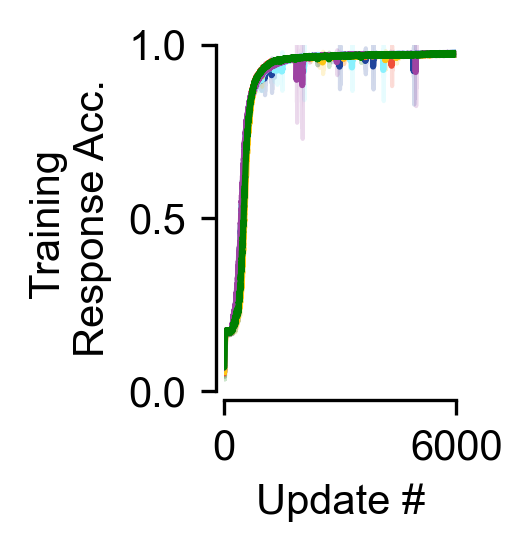

In [7]:
exp_strs = ["gd_log_normal", "eg_log_normal", "gd_normal", "eg_normal", "gd_uniform", "eg_uniform"]
key = "Dec Acc"
xlims = (0, 6000)
ylims = (0, 1)

plt.figure(figsize=(1.,1.5), dpi = 300)
for exp_name in exp_strs:
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    print(array[-1], std_dev[-1], results_dict[exp_name].train_results[key].shape)
    n_updates = array.shape[0]
    plt.plot(np.arange(1,n_updates+1), array, c=results_dict[exp_name].c, label=exp_name)
    plt.fill_between(np.arange(1,n_updates+1), array-std_dev, array+std_dev, color=results_dict[exp_name].c, alpha=0.2)
ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx: plt.xscale("log")
if logy: plt.yscale("log")

y_step = 0.5
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Training \nResponse Acc.", rotation=90)

#sns.despine()
sns.despine(offset=2, trim=True)

# plt.tight_layout()
# plt.savefig("figs/fig1/1c_response_acc.pdf", bbox_inches="tight", transparent=True)
# plt.savefig("figs/fig1/1c_decacc_training_uni.png", bbox_inches="tight")

(5,)
0.9839465757608412 4.2723772285107356e-05
(5,)
0.9839160858392717 5.590861774628249e-05
(5,)
0.9839983574151991 8.120929390659354e-05
(5,)
0.9838824610710144 3.0568981505504614e-05
(5,)
0.9839582927227021 4.835310505332963e-05
(5,)
0.98394338285923 7.883715502770219e-05


Text(0, 0.5, 'Test \nResponse Acc.')

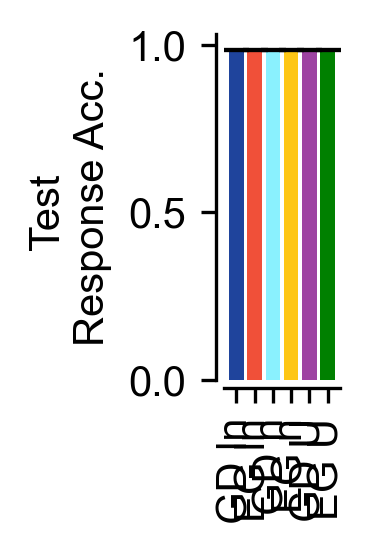

In [9]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(0.5,1.5), dpi = 300)
exp_labels = ["GD ln", "EG ln", "GD n", "EG n", "GD U", "EG U"]
colours = [results_dict[exp_str].c for exp_str in exp_strs]
key = "test_Dec_Acc"
means = []
std_devs = []
for exp_name in exp_strs:
    array = results_dict[exp_name].eval_results[key][-1,:] # last epoch, all seeds
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3, width=0.8)
sns.despine(offset=2)
plt.xticks(rotation=90)
plt.ylabel("Test \nResponse Acc.")
# plt.savefig("figs/fig1/1c_response_acc_test.pdf", bbox_inches="tight", transparent=True)


### Final weight distribution plots

In [10]:
from scipy.stats import norm

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)

def get_checkpoint_name(results, seed, epoch_idx):
    return str(results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt'


def plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6,
                      zero_th=None, log_weights=False, log_y_scale=False, kde=False, stat='proportion',
                     gaussian_approx=False, seperate_plots=True, xlims_step=None, ylims_step=None, 
                      figsize_tuple=None, axis_off=False):
    print("Todo: suppress / correct warnings!")
    if figsize_tuple is None: 
        figsize_tuple = (1.5,1.5)
    fig = plt.figure(figsize=figsize_tuple, dpi = 300)
    for seed in ["seed_7"]:#,"seed_6","seed_7","seed_8","seed_9"]:
        #plt.title(seed)
        print(type(fig))
        if seperate_plots:
            # Add an axes to the figure at position [left, bottom, width, height]
            # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
            # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
            ax_eg = fig.add_axes([0.0, 0., 0.8, .4])
            ax_gd = fig.add_axes([0.0, 0.5, 0.8, .4])
        else:
            ax_eg = fig.add_subplot(111)
            ax_gd = ax_eg

        gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        print(str(eg_exp_results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt')
        
        gd_key = eg_key.replace("base_layer.", "")

        gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
        eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()

        gd_arr = np.abs(gd_arr)
        eg_arr = np.abs(eg_arr)
        
        if zero_th is not None:
            gd_arr = gd_arr[gd_arr > zero_th]
            eg_arr = eg_arr[eg_arr > zero_th]
        if log_weights:
            gd_arr = np.log(gd_arr)
            eg_arr = np.log(eg_arr)
    #     gd_arr = np.where(np.isinf(gd_arr), np.nan, gd_arr)
    #     eg_arr = np.where(np.isinf(eg_arr), np.nan, eg_arr)

#         print(f"GD: std {np.std(gd_arr)}, skew {stats.skew(gd_arr)}, kurtosis  {stats.kurtosis(gd_arr)}")
#         print(f"EG: std {np.std(eg_arr)}, skew {stats.skew(eg_arr)}, kurtosis  {stats.kurtosis(eg_arr)}")
        max_weight = np.max([np.max(eg_arr), np.max(gd_arr)])
        bin_edges = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 50)

        sns.histplot(eg_arr, bins = bin_edges, kde=kde, stat=stat, color=eg_exp_results.c, ec=None,
                    label='EG', ax=ax_eg)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_eg.plot(points, get_norm_pdf(points, eg_arr.mean(), eg_arr.std()), color=eg_exp_results.c,
                    linestyle='--')
        
        sns.histplot(gd_arr, bins = bin_edges, kde=kde, stat=stat, color=gd_exp_results.c, ec=None, alpha=0.5,
                    label='GD', ax=ax_gd)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_gd.plot(points, get_norm_pdf(points, gd_arr.mean(), gd_arr.std()), color=gd_exp_results.c,
                    linestyle='--')
            
        if ylims_step is not None:
            ticks = np.arange(ylims_step[0],ylims_step[1]+ylims_step[2], ylims_step[2])
            ax_eg.set_yticks(ticks)
            ax_eg.set_ylim(ylims_step[0],ylims_step[1])

            ax_gd.set_yticks(ticks)
            ax_gd.set_ylim(ylims_step[0],ylims_step[1])
            

        if xlims_step is not None:
            ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])
            ax_eg.set_xticks(ticks)
            ax_eg.set_xlim(xlims_step[0],xlims_step[1])

            ax_gd.set_xticks(ticks)
            ax_gd.set_xlim(xlims_step[0],xlims_step[1])

        # Manually set the same x-limits for both subplots
        x_limits = (min(ax_eg.get_xlim()[0], ax_gd.get_xlim()[0])-0.01, max(ax_eg.get_xlim()[1], ax_gd.get_xlim()[1]))
        ax_eg.set_xlim(x_limits)
        ax_gd.set_xlim(x_limits)
        print(f"x_lims are {x_limits}")

        sns.despine(offset=2, trim=True, ax=ax_eg)
        sns.despine(offset=2, trim=True, ax=ax_gd) 
        if seperate_plots:
            #ax_gd.spines['left'].set_visible(False)
            ax_gd.spines['bottom'].set_visible(False)
            ax_gd.xaxis.set_visible(False)
            
        ax_gd.set_xlabel(r"$\log |w^{rec}|$")

        if log_y_scale: plt.yscale("log")
        #if stat != 'count': plt.legend(loc='upper left')
        if axis_off: 
            ax_gd.axis("off")
            ax_eg.axis("off")
        plt.show()
        return fig


In [11]:
# z-score and then plot mean cdf + individual lines + Gaussian cdf
def get_param_arrs(eg_exp_results, gd_exp_results, eg_key, epoch_idx, log_weights=True, zero_th=None):
    if zero_th is not None: print("Zero threshold not implemented")
    seed_keys = [k for k in eg_exp_results.keys() if k.startswith("seed")]
    gd_arr_dict = {}
    eg_arr_dict = {}
    for seed in seed_keys:#,"seed_6","seed_7","seed_8","seed_9"]:
        gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                                map_location=torch.device('cpu'))
        
        eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                                map_location=torch.device('cpu'))
        
        gd_key = eg_key.replace("base_layer.", "")

        gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
        eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()

        gd_arr = np.abs(gd_arr)
        eg_arr = np.abs(eg_arr)

        # commented out bec of concat failing at end
        # replace with
        # if zero_th is not None:
        #     gd_arr = gd_arr[gd_arr > zero_th]
        #     eg_arr = eg_arr[eg_arr > zero_th]

        if log_weights:
            gd_arr = np.log(gd_arr + 1e-9 * (gd_arr == 0))
            eg_arr = np.log(eg_arr + 1e-9 * (eg_arr == 0))

        gd_arr_dict[seed] = gd_arr[:,None]
        eg_arr_dict[seed] = eg_arr[:,None]

    gd_arr = np.concatenate(list(gd_arr_dict.values()), axis=1)
    eg_arr = np.concatenate(list(eg_arr_dict.values()), axis=1)
    return eg_arr, gd_arr

def z_score_arr(arr, axis=0):
    """axis 0 to z-score each column seperately"""
    mean = np.mean(arr, axis=axis)
    std = np.std(arr, axis=axis)
    return (arr - mean) / std


def get_pair_of_zscored_results(eg_exp_results, gd_exp_results):
    eg_key="rnn.base_layer.weight_hh"
    epoch_idx = 6

    eg_arr, gd_arr = get_param_arrs(eg_exp_results, gd_exp_results, eg_key, epoch_idx, zero_th=6e-5)

    # note not removing zero thresholds, so not same scale
    #print(np.sort(eg_arr[:,1]))

    eg_arr_z = z_score_arr(eg_arr, axis=0)
    gd_arr_z = z_score_arr(gd_arr, axis=0)

    #print(np.sort(eg_arr_z[:,1]))

    # Verify
    print("Mean of each column after z-scoring (should be close to 0):")
    print(np.mean(eg_arr_z, axis=0))
    print("Standard deviation of each column after z-scoring (should be 1):")
    print(np.std(eg_arr_z, axis=0))
    return eg_arr_z, gd_arr_z


Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
x_lims are (-10.01, 2.0)


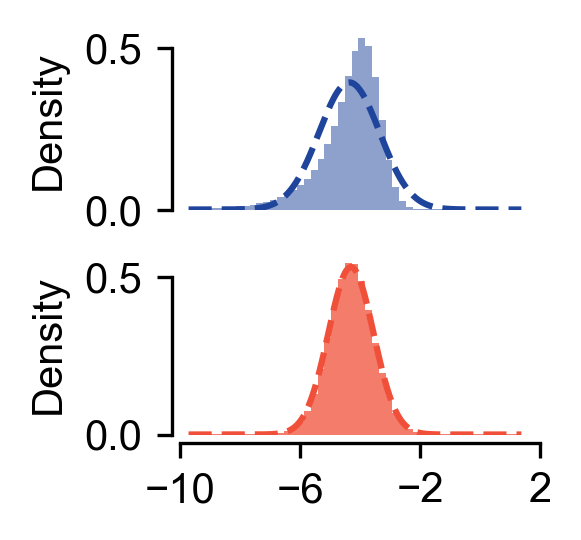

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
x_lims are (-10.01, 2.0)


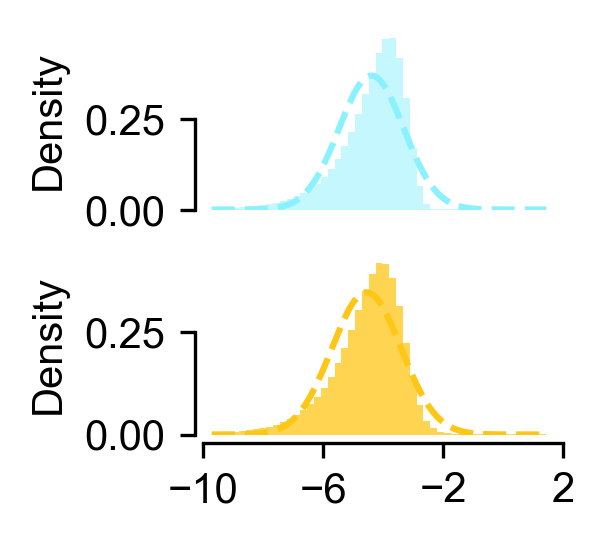

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
x_lims are (-10.01, 2.0)


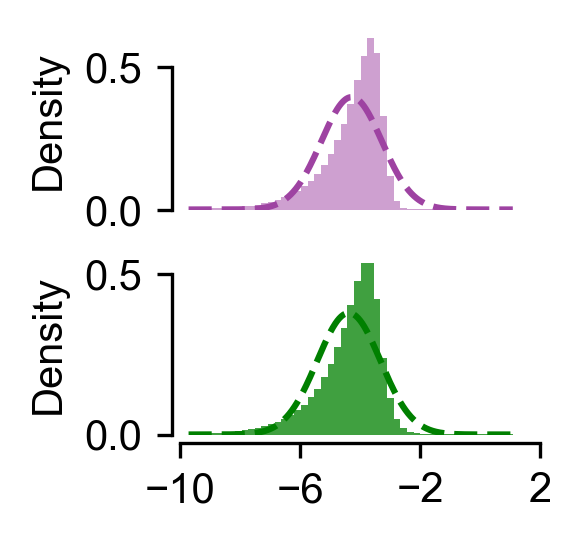

In [12]:
eg_exp_results = results_dict.eg_log_normal
gd_exp_results = results_dict.gd_log_normal

fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4))  # 1e-5 for log weights

fig.savefig("figs/figS2/ln_weights_hists.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_normal
gd_exp_results = results_dict.gd_normal

fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4))  # 1e-5 for log weights

fig.savefig("figs/figS2/n_weights_hists.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_uniform
gd_exp_results = results_dict.gd_uniform

fig = plot_weight_hists(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", epoch_idx=6, 
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4))  # 1e-5 for log weights

fig.savefig("figs/figS2/u_weights_hists.pdf", bbox_inches="tight", transparent=True)

In [13]:
eg_arr_z_ln, gd_arr_z_ln = get_pair_of_zscored_results(results_dict.eg_log_normal, results_dict.gd_log_normal)
eg_arr_z_n, gd_arr_z_n = get_pair_of_zscored_results(results_dict.eg_normal, results_dict.gd_normal)
eg_arr_z_u, gd_arr_z_u = get_pair_of_zscored_results(results_dict.eg_uniform, results_dict.gd_uniform)

Zero threshold not implemented
Mean of each column after z-scoring (should be close to 0):
[ 5.73396856e-13 -1.11866291e-14 -2.64134670e-13  5.29740358e-13
 -3.22799805e-13]
Standard deviation of each column after z-scoring (should be 1):
[1. 1. 1. 1. 1.]
Zero threshold not implemented
Mean of each column after z-scoring (should be close to 0):
[ 8.51518073e-14 -7.31300018e-14 -2.05430745e-13  1.73865715e-13
 -4.52539548e-13]
Standard deviation of each column after z-scoring (should be 1):
[1. 1. 1. 1. 1.]
Zero threshold not implemented
Mean of each column after z-scoring (should be close to 0):
[ 1.21166140e-13  4.39501742e-14 -1.44568016e-13  3.22104782e-13
  6.75637770e-13]
Standard deviation of each column after z-scoring (should be 1):
[1. 1. 1. 1. 1.]


In [14]:
gd_stat_ln = np.zeros(gd_arr_z_ln.shape[1])
eg_stat_ln = np.zeros(gd_arr_z_ln.shape[1])
gd_stat_n = np.zeros(gd_arr_z_ln.shape[1])
eg_stat_n = np.zeros(gd_arr_z_ln.shape[1])
gd_stat_u = np.zeros(gd_arr_z_ln.shape[1])
eg_stat_u = np.zeros(gd_arr_z_ln.shape[1])

for seed in range(gd_arr_z_ln.shape[1]):
    gd_stat_ln[seed] = stats.kstest(gd_arr_z_ln[:, seed], stats.norm.cdf).statistic
    eg_stat_ln[seed] = stats.kstest(eg_arr_z_ln[:, seed], stats.norm.cdf).statistic
    gd_stat_n[seed] = stats.kstest(gd_arr_z_n[:, seed], stats.norm.cdf).statistic
    eg_stat_n[seed] = stats.kstest(eg_arr_z_n[:, seed], stats.norm.cdf).statistic
    gd_stat_u[seed] = stats.kstest(gd_arr_z_u[:, seed], stats.norm.cdf).statistic
    eg_stat_u[seed] = stats.kstest(eg_arr_z_u[:, seed], stats.norm.cdf).statistic

(5,)
0.09958244659698966 0.00020701399367565066
(5,)
0.011044145744119693 7.842437914235691e-05
(5,)
0.0950252299203492 0.00012286712938404254
(5,)
0.07954592825073169 0.00022890157177856346
(5,)
0.11610314961212684 0.00036672197824813406
(5,)
0.10545881579625069 0.00039438183746119


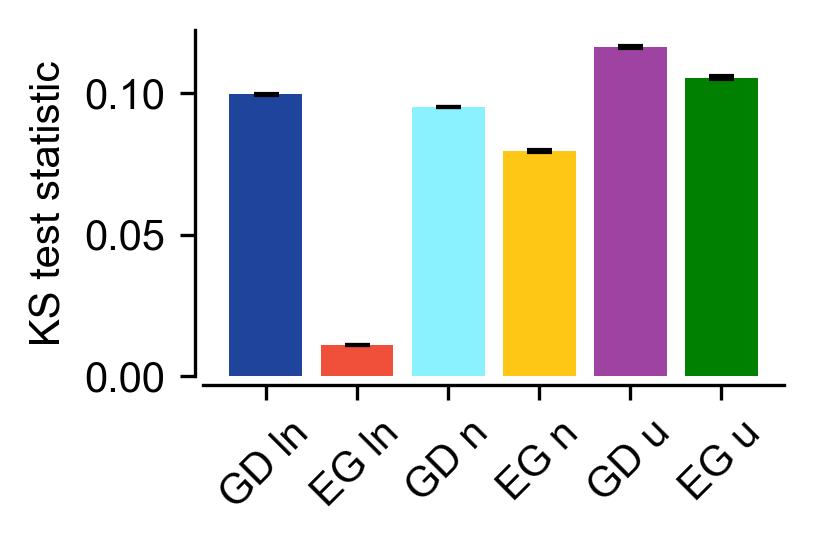

In [15]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(2.5,1.5), dpi = 300)
exp_labels = ["GD ln", "EG ln", "GD n", "EG n", "GD u", "EG u"]
colours = [results_dict.gd_log_normal.c, results_dict.eg_log_normal.c, 
           results_dict.gd_normal.c, results_dict.eg_normal.c,
           results_dict.gd_uniform.c, results_dict.eg_uniform.c]
key = "test_Dec_Acc"
means = []
std_devs = []
for array in [gd_stat_ln, eg_stat_ln, gd_stat_n, eg_stat_n, gd_stat_u, eg_stat_u]:
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3,width=0.8 )
sns.despine(offset=2)

plt.ylabel("KS test statistic")
plt.xticks(rotation=45)
plt.savefig("figs/figS2/KS_cdf_ttest.pdf", bbox_inches="tight", transparent=True)


## Same plots but for changes from init

In [16]:
def plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                           epoch_idx_final=6, epoch_idx_init=0,
                      zero_th=None, log_weights=False, log_y_scale=False, kde=False, stat='proportion',
                     gaussian_approx=False, seperate_plots=True, xlims_step=None, ylims_step=None, 
                      figsize_tuple=None, axis_off=False):
    print("Todo: suppress / correct warnings!")
    if figsize_tuple is None: 
        figsize_tuple = (1.5,1.5)
    fig = plt.figure(figsize=figsize_tuple, dpi = 300)
    for seed in ["seed_7"]:#,"seed_6","seed_7","seed_8","seed_9"]:
        #plt.title(seed)
        print(type(fig))
        if seperate_plots:
            # Add an axes to the figure at position [left, bottom, width, height]
            # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
            # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
            ax_eg = fig.add_axes([0.0, 0., 0.8, .4])
            ax_gd = fig.add_axes([0.0, 0.5, 0.8, .4])
        else:
            ax_eg = fig.add_subplot(111)
            ax_gd = ax_eg

        def get_eg_gd_res(epoch_idx):
            gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                                 map_location=torch.device('cpu'))
            eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                                 map_location=torch.device('cpu'))
            print(str(eg_exp_results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt')

            gd_key = eg_key.replace("base_layer.", "")

            gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
            eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()
        
            return eg_arr, gd_arr
        
        eg_arr_final, gd_arr_final = get_eg_gd_res(epoch_idx_final)
        eg_arr_init, gd_arr_init = get_eg_gd_res(epoch_idx_init)
        
        
        if log_weights:
            gd_same_sign = gd_arr_final * gd_arr_init >= 0
            print(f'Proportion of GD weights with the same sign before/after: {gd_same_sign.sum() / len(gd_arr_final)} \
            \nOnly those are plotted!')
            
            gd_arr_final, gd_arr_init = np.abs(gd_arr_final), np.abs(gd_arr_init)
            eg_arr_final, eg_arr_init = np.abs(eg_arr_final), np.abs(eg_arr_init) 

            if zero_th is not None:
                gd_th_idx = (gd_arr_final > zero_th) * (gd_arr_init > zero_th)
                eg_th_idx = (eg_arr_final > zero_th) * (eg_arr_init > zero_th)
                print(f'Threshold GD: {gd_th_idx.sum() / len(gd_arr_final)}')
                print(f'Threshold EG: {eg_th_idx.sum() / len(eg_arr_final)}')
                
            gd_arr_final, gd_arr_init = np.log(gd_arr_final[gd_same_sign * gd_th_idx]), \
                np.log(gd_arr_init[gd_same_sign * gd_th_idx])
            eg_arr_final, eg_arr_init = np.log(eg_arr_final[eg_th_idx]), np.log(eg_arr_init[eg_th_idx]) 
        
        eg_arr = eg_arr_final - eg_arr_init
        gd_arr = gd_arr_final - gd_arr_init
        
        if not log_weights:
            print('\nOnly plotting 0.5/99.5th percentiles of weights for sane looking histograms\n')
            eg_percentiles = np.percentile(eg_arr, (0.5, 99.5))
            eg_arr = eg_arr[(eg_arr >= eg_percentiles[0]) * (eg_arr <= eg_percentiles[1])]
            gd_percentiles = np.percentile(gd_arr, (0.5, 99.5))
            gd_arr = gd_arr[(gd_arr >= gd_percentiles[0]) * (gd_arr <= gd_percentiles[1])]
        
#         print(f"GD: std {np.std(gd_arr)}, skew {stats.skew(gd_arr)}, kurtosis  {stats.kurtosis(gd_arr)}")
#         print(f"EG: std {np.std(eg_arr)}, skew {stats.skew(eg_arr)}, kurtosis  {stats.kurtosis(eg_arr)}")
        max_weight = np.max([np.max(eg_arr), np.max(gd_arr)])
        bin_edges = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 50)

        sns.histplot(eg_arr, bins = bin_edges, kde=kde, stat=stat, color=eg_exp_results.c, ec=None,
                    label='EG', ax=ax_eg)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_eg.plot(points, get_norm_pdf(points, eg_arr.mean(), eg_arr.std()), color=eg_exp_results.c,
                    linestyle='--')
        
        sns.histplot(gd_arr, bins = bin_edges, kde=kde, stat=stat, color=gd_exp_results.c, ec=None, alpha=0.5,
                    label='GD', ax=ax_gd)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(eg_arr), np.min(gd_arr)])), max_weight, 500)
            ax_gd.plot(points, get_norm_pdf(points, gd_arr.mean(), gd_arr.std()), color=gd_exp_results.c,
                    linestyle='--')
            
        if ylims_step is not None:
            ticks = np.arange(ylims_step[0],ylims_step[1]+ylims_step[2], ylims_step[2])
            ax_eg.set_yticks(ticks)
            ax_eg.set_ylim(ylims_step[0],ylims_step[1])

            ax_gd.set_yticks(ticks)
            ax_gd.set_ylim(ylims_step[0],ylims_step[1])
            

        if xlims_step is not None:
            ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])
            ax_eg.set_xticks(ticks)
            ax_eg.set_xlim(xlims_step[0],xlims_step[1])

            ax_gd.set_xticks(ticks)
            ax_gd.set_xlim(xlims_step[0],xlims_step[1])

        # Manually set the same x-limits for both subplots
        x_limits = (min(ax_eg.get_xlim()[0], ax_gd.get_xlim()[0])-0.01, max(ax_eg.get_xlim()[1], ax_gd.get_xlim()[1]))
        ax_eg.set_xlim(x_limits)
        ax_gd.set_xlim(x_limits)
        print(f"x_lims are {x_limits}")

        sns.despine(offset=2, trim=True, ax=ax_eg)
        sns.despine(offset=2, trim=True, ax=ax_gd) 
        if seperate_plots:
            #ax_gd.spines['left'].set_visible(False)
            ax_gd.spines['bottom'].set_visible(False)
            ax_gd.xaxis.set_visible(False)
            
        if log_weights:
            ax_gd.set_xlabel(r"$\log |w^{rec}_{final}| - \log |w^{rec}_{init}|$")
        else:
            ax_gd.set_xlabel(r"$w^{rec}_{final} - w^{rec}_{init}$")

        if log_y_scale: plt.yscale("log")
        #if stat != 'count': plt.legend(loc='upper left')
        if axis_off: 
            ax_gd.axis("off")
            ax_eg.axis("off")
        plt.show()
        return fig


### Log weights diff

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_0.pt
Proportion of GD weights with the same sign before/after: 0.88875328             
Only those are plotted!
Threshold GD: 0.99822544
Threshold EG: 0.99987632
x_lims are (-4.01, 4.0)


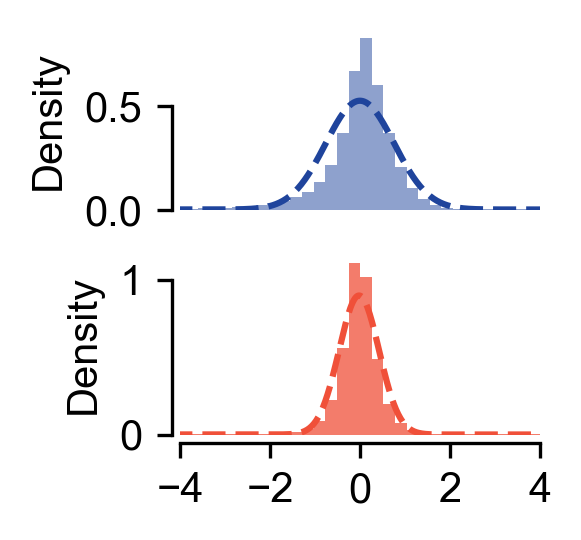

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_0.pt
Proportion of GD weights with the same sign before/after: 0.84842032             
Only those are plotted!
Threshold GD: 0.99553296
Threshold EG: 0.9967928
x_lims are (-4.01, 4.0)


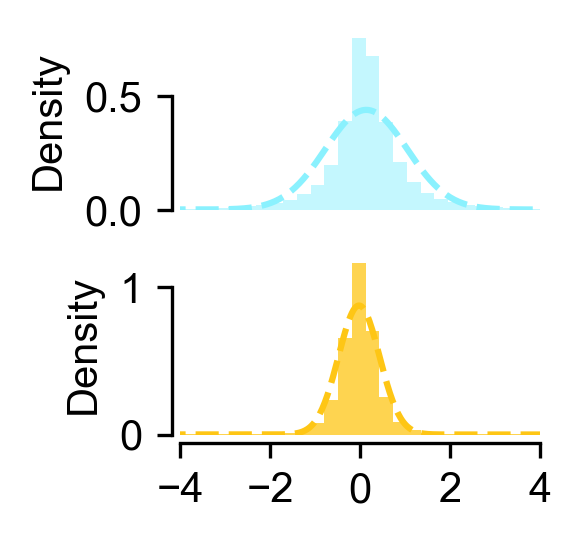

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_0.pt
Proportion of GD weights with the same sign before/after: 0.87841904             
Only those are plotted!
Threshold GD: 0.99657232
Threshold EG: 0.99771072
x_lims are (-4.01, 4.0)


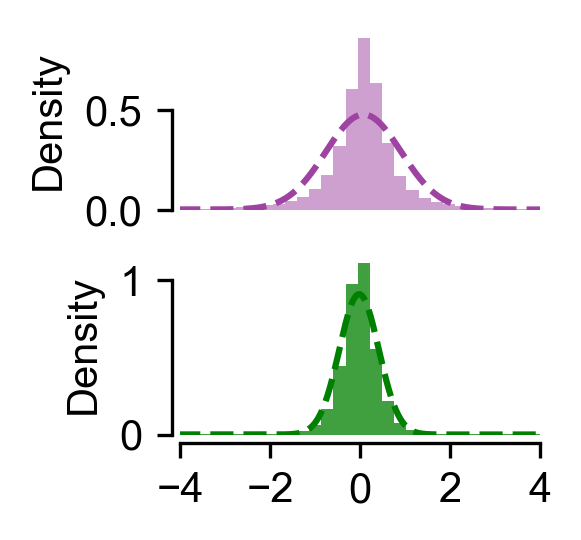

In [17]:
eg_exp_results = results_dict.eg_log_normal
gd_exp_results = results_dict.gd_log_normal

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-4, 4, 2))  # 1e-5 for log weights

fig.savefig("figs/figS2/ln_weights_diff_hists_log_space.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_normal
gd_exp_results = results_dict.gd_normal

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-4, 4, 2))  # 1e-5 for log weights

fig.savefig("figs/figS2/n_weights_diff_hists_log_space.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_uniform
gd_exp_results = results_dict.gd_uniform

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-4, 4, 2))  # 1e-5 for log weights

fig.savefig("figs/figS2/u_weights_diff_hists_log_space.pdf", bbox_inches="tight", transparent=True)

### No log weight diff

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_0.pt

Only plotting 0.5/99.5th percentiles of weights for sane looking histograms

x_lims are (-0.060000000000000005, 0.05)


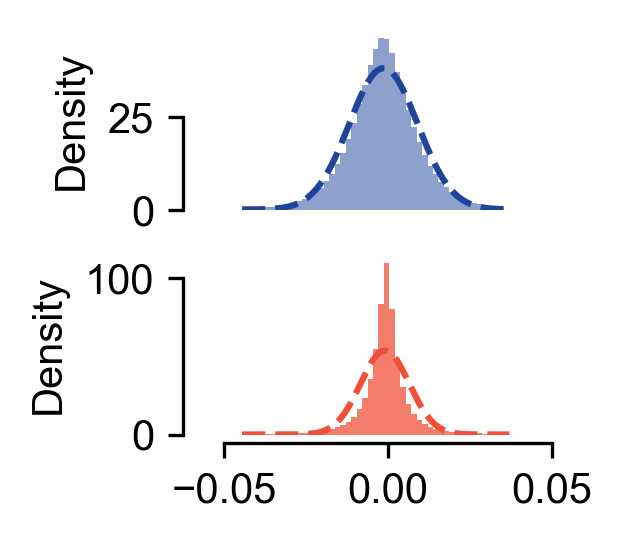

Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt
/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_0.pt

Only plotting 0.5/99.5th percentiles of weights for sane looking histograms



In [ ]:
eg_exp_results = results_dict.eg_log_normal
gd_exp_results = results_dict.gd_log_normal

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=False, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-0.05, 0.05, 0.05))  # 1e-5 for log weights

fig.savefig("figs/figS2/ln_weights_diff_hists_primal_space.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_normal
gd_exp_results = results_dict.gd_normal

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=False, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-0.05, 0.05, 0.05))  # 1e-5 for log weights

fig.savefig("figs/figS2/n_weights_diff_hists_primal_space.pdf", bbox_inches="tight", transparent=True)

eg_exp_results = results_dict.eg_uniform
gd_exp_results = results_dict.gd_uniform

fig = plot_weight_hists_diff(eg_exp_results, gd_exp_results, eg_key="rnn.base_layer.weight_hh", 
                             epoch_idx_final=6, epoch_idx_init=0,
                  zero_th=6e-5, log_weights=False, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-0.05, 0.05, 0.05))  # 1e-5 for log weights

fig.savefig("figs/figS2/u_weights_diff_hists_primal_space.pdf", bbox_inches="tight", transparent=True)

In [ ]:
# z-score and then plot mean cdf + individual lines + Gaussian cdf
def get_eg_gd_res_single_seed(gd_exp_results, eg_exp_results, seed, epoch_idx_final, epoch_idx_init, 
                              log_weights, zero_th, gd_key, eg_key):
    def get_eg_gd_res(epoch_idx):
        gd_ckpt = torch.load(get_checkpoint_name(gd_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        eg_ckpt = torch.load(get_checkpoint_name(eg_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        print(str(eg_exp_results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt')

        gd_key = eg_key.replace("base_layer.", "")

        gd_arr = gd_ckpt[gd_key].flatten().detach().numpy()
        eg_arr = eg_ckpt[eg_key].flatten().detach().numpy()

        return eg_arr, gd_arr

    eg_arr_final, gd_arr_final = get_eg_gd_res(epoch_idx_final)
    eg_arr_init, gd_arr_init = get_eg_gd_res(epoch_idx_init)


    if log_weights:
        gd_same_sign = gd_arr_final * gd_arr_init >= 0
        print(f'Proportion of GD weights with the same sign before/after: {gd_same_sign.sum() / len(gd_arr_final)} \
        \nOnly those are plotted!')

        gd_arr_final, gd_arr_init = np.abs(gd_arr_final), np.abs(gd_arr_init)
        eg_arr_final, eg_arr_init = np.abs(eg_arr_final), np.abs(eg_arr_init) 
    
        gd_arr_final = np.log(gd_arr_final + 1e-9 * (gd_arr_final == 0))[gd_same_sign]
        gd_arr_init = np.log(gd_arr_init + 1e-9 * (gd_arr_init == 0))[gd_same_sign]
        eg_arr_final = np.log(eg_arr_final + 1e-9 * (eg_arr_final == 0))
        eg_arr_init = np.log(eg_arr_init + 1e-9 * (eg_arr_init == 0))
            
#         if zero_th is not None:
#             gd_th_idx = (gd_arr_final > zero_th) * (gd_arr_init > zero_th)
#             eg_th_idx = (eg_arr_final > zero_th) * (eg_arr_init > zero_th)
#             print(f'Threshold GD: {gd_th_idx.sum() / len(gd_arr_final)}')
#             print(f'Threshold EG: {eg_th_idx.sum() / len(eg_arr_final)}')

#         gd_arr_final, gd_arr_init = np.log(gd_arr_final[gd_same_sign * gd_th_idx]), \
#             np.log(gd_arr_init[gd_same_sign * gd_th_idx])
#         eg_arr_final, eg_arr_init = np.log(eg_arr_final[eg_th_idx]), np.log(eg_arr_init[eg_th_idx]) 

    eg_arr = eg_arr_final - eg_arr_init
    gd_arr = gd_arr_final - gd_arr_init
    
#     print('\nOnly plotting 0.5/99.5th percentiles of weights for sane looking histograms\n')
#     eg_percentiles = np.percentile(eg_arr, (0.5, 99.5))
#     eg_arr = eg_arr[(eg_arr >= eg_percentiles[0]) * (eg_arr <= eg_percentiles[1])]
#     gd_percentiles = np.percentile(gd_arr, (0.5, 99.5))
#     gd_arr = gd_arr[(gd_arr >= gd_percentiles[0]) * (gd_arr <= gd_percentiles[1])]
    
    return eg_arr, gd_arr


def get_param_arrs_diff(eg_exp_results, gd_exp_results, eg_key, *, log_weights=True, zero_th=None,
                  epoch_idx_final=6, epoch_idx_init=0):
    gd_key = eg_key.replace("base_layer.", "")
    seed_keys = [k for k in eg_exp_results.keys() if k.startswith("seed")]
    gd_arr_dict = {}
    eg_arr_dict = {}
    for seed in seed_keys:#,"seed_6","seed_7","seed_8","seed_9"]:
        eg_arr_dict[seed], gd_arr_dict[seed] = get_eg_gd_res_single_seed(gd_exp_results, eg_exp_results, seed, epoch_idx_final, epoch_idx_init, 
                              log_weights, zero_th, gd_key, eg_key)
    return eg_arr_dict, gd_arr_dict


def get_pair_of_zscored_results_diff(eg_exp_results, gd_exp_results,log_weights=True, zero_th=None,
                  epoch_idx_final=6, epoch_idx_init=0):
    eg_key="rnn.base_layer.weight_hh"

    eg_arr_dict, gd_arr_dict = get_param_arrs_diff(eg_exp_results, gd_exp_results, eg_key, 
                                         log_weights=log_weights, zero_th=zero_th,
                                         epoch_idx_final=epoch_idx_final, epoch_idx_init=epoch_idx_init)

    # note not removing zero thresholds, so not same scale
    #print(np.sort(eg_arr[:,1]))

    for key in eg_arr_dict.keys():
        eg_arr_dict[key] = z_score_arr(eg_arr_dict[key], axis=0)
        gd_arr_dict[key] = z_score_arr(gd_arr_dict[key], axis=0)

    return eg_arr_dict, gd_arr_dict


### Log weights

In [ ]:
log_weights = True
eg_arr_z_ln, gd_arr_z_ln = get_pair_of_zscored_results_diff(results_dict.eg_log_normal, results_dict.gd_log_normal,
                                                           zero_th=6e-5, log_weights=log_weights)
eg_arr_z_n, gd_arr_z_n = get_pair_of_zscored_results_diff(results_dict.eg_normal, results_dict.gd_normal,
                                                           zero_th=6e-5, log_weights=log_weights)
eg_arr_z_u, gd_arr_z_u = get_pair_of_zscored_results_diff(results_dict.eg_uniform, results_dict.gd_uniform,
                                                           zero_th=6e-5, log_weights=log_weights)

In [116]:
n_seeds = len(gd_arr_z_ln.keys())
gd_stat_ln = np.zeros(n_seeds)
eg_stat_ln = np.zeros(n_seeds)
gd_stat_n = np.zeros(n_seeds)
eg_stat_n = np.zeros(n_seeds)
gd_stat_u = np.zeros(n_seeds)
eg_stat_u = np.zeros(n_seeds)

for seed, key in enumerate(gd_arr_z_ln.keys()):
    gd_stat_ln[seed] = stats.kstest(gd_arr_z_ln[key], stats.norm.cdf).statistic
    eg_stat_ln[seed] = stats.kstest(eg_arr_z_ln[key], stats.norm.cdf).statistic
    gd_stat_n[seed] = stats.kstest(gd_arr_z_n[key], stats.norm.cdf).statistic
    eg_stat_n[seed] = stats.kstest(eg_arr_z_n[key], stats.norm.cdf).statistic
    gd_stat_u[seed] = stats.kstest(gd_arr_z_u[key], stats.norm.cdf).statistic
    eg_stat_u[seed] = stats.kstest(eg_arr_z_u[key], stats.norm.cdf).statistic

In [ ]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(2.5,1.5), dpi = 300)
exp_labels = ["GD ln", "EG ln", "GD n", "EG n", "GD u", "EG u"]
colours = [results_dict.gd_log_normal.c, results_dict.eg_log_normal.c, 
           results_dict.gd_normal.c, results_dict.eg_normal.c,
           results_dict.gd_uniform.c, results_dict.eg_uniform.c]
key = "test_Dec_Acc"
means = []
std_devs = []
for array in [gd_stat_ln, eg_stat_ln, gd_stat_n, eg_stat_n, gd_stat_u, eg_stat_u]:
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3,width=0.8 )
sns.despine(offset=2)

plt.ylabel("KS test statistic")
plt.xticks(rotation=45)
plt.savefig("figs/figS2/KS_diff_cdf_ttest_log_space.pdf", bbox_inches="tight", transparent=True)


## Not log change

In [ ]:
log_weights = False
eg_arr_z_ln, gd_arr_z_ln = get_pair_of_zscored_results_diff(results_dict.eg_log_normal, results_dict.gd_log_normal,
                                                           zero_th=6e-5, log_weights=log_weights)
eg_arr_z_n, gd_arr_z_n = get_pair_of_zscored_results_diff(results_dict.eg_normal, results_dict.gd_normal,
                                                           zero_th=6e-5, log_weights=log_weights)
eg_arr_z_u, gd_arr_z_u = get_pair_of_zscored_results_diff(results_dict.eg_uniform, results_dict.gd_uniform,
                                                           zero_th=6e-5, log_weights=log_weights)

In [119]:
n_seeds = len(gd_arr_z_ln.keys())
gd_stat_ln = np.zeros(n_seeds)
eg_stat_ln = np.zeros(n_seeds)
gd_stat_n = np.zeros(n_seeds)
eg_stat_n = np.zeros(n_seeds)
gd_stat_u = np.zeros(n_seeds)
eg_stat_u = np.zeros(n_seeds)

for seed, key in enumerate(gd_arr_z_ln.keys()):
    gd_stat_ln[seed] = stats.kstest(gd_arr_z_ln[key], stats.norm.cdf).statistic
    eg_stat_ln[seed] = stats.kstest(eg_arr_z_ln[key], stats.norm.cdf).statistic
    gd_stat_n[seed] = stats.kstest(gd_arr_z_n[key], stats.norm.cdf).statistic
    eg_stat_n[seed] = stats.kstest(eg_arr_z_n[key], stats.norm.cdf).statistic
    gd_stat_u[seed] = stats.kstest(gd_arr_z_u[key], stats.norm.cdf).statistic
    eg_stat_u[seed] = stats.kstest(eg_arr_z_u[key], stats.norm.cdf).statistic

In [ ]:
# bar chart showing final accuracy across the different weight distributions

plt.figure(figsize=(2.5,1.5), dpi = 300)
exp_labels = ["GD ln", "EG ln", "GD n", "EG n", "GD u", "EG u"]
colours = [results_dict.gd_log_normal.c, results_dict.eg_log_normal.c, 
           results_dict.gd_normal.c, results_dict.eg_normal.c,
           results_dict.gd_uniform.c, results_dict.eg_uniform.c]
key = "test_Dec_Acc"
means = []
std_devs = []
for array in [gd_stat_ln, eg_stat_ln, gd_stat_n, eg_stat_n, gd_stat_u, eg_stat_u]:
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3,width=0.8 )
sns.despine(offset=2)

plt.ylabel("KS test statistic")
plt.xticks(rotation=45)
plt.savefig("figs/figS2/KS_diff_cdf_ttest_primal_space.pdf", bbox_inches="tight", transparent=True)
